# CAMA 5-Seed Results: Amazon item-ltv + Avito Negative Gate Init Fix

**Cardinality-Aware Moment Aggregation (CAMA)** extends standard mean aggregation in Graph Neural Networks by incorporating variance information gated by neighborhood cardinality and effective rank.

This notebook demonstrates:
1. **CAMA aggregation module** — implementation and unit tests on synthetic data
2. **Statistical analysis** — Cohen's d, paired t-test, Wilcoxon signed-rank on pre-computed 5-seed results
3. **Results visualization** — comparing mean baseline vs CAMA variants on Amazon (item-ltv) and Avito (ad-ctr) tasks

**Key findings:**
- Amazon CAMA showed degradation (Cohen's d = -1.38)
- Avito CAMA-default was 4.7% worse than mean baseline
- Avito CAMA-neg-init (gate_bias=-3) was 14.7% worse, failing the 5% safety check

In [1]:
import subprocess, sys
def _pip(*a): subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', *a])

# Core packages (pre-installed on Colab, install locally to match Colab env)
if 'google.colab' not in sys.modules:
    _pip('numpy==2.0.2', 'scipy==1.15.3', 'matplotlib==3.10.0', 'tabulate==0.9.0')
    _pip('torch', '--index-url', 'https://download.pytorch.org/whl/cpu')

# torch_geometric — NOT pre-installed on Colab, always install
_pip('torch_geometric')


[notice] A new release of pip is available: 23.0.1 -> 26.0.1
[notice] To update, run: python3 -m pip install --upgrade pip



[notice] A new release of pip is available: 23.0.1 -> 26.0.1
[notice] To update, run: python3 -m pip install --upgrade pip



[notice] A new release of pip is available: 23.0.1 -> 26.0.1
[notice] To update, run: python3 -m pip install --upgrade pip


In [2]:
import copy
import json
import math
import os
import warnings

import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
from scipy import stats as sp_stats
from torch import Tensor
from torch_geometric.nn.aggr import Aggregation, MeanAggregation
from torch_geometric.nn.conv import SAGEConv

warnings.filterwarnings("ignore", category=UserWarning)
warnings.filterwarnings("ignore", category=FutureWarning)

print(f"PyTorch: {torch.__version__}")
print(f"NumPy: {np.__version__}")
print(f"Device: {'cuda' if torch.cuda.is_available() else 'cpu'}")

PyTorch: 2.10.0+cpu
NumPy: 2.0.2
Device: cpu


In [3]:
GITHUB_DATA_URL = "https://raw.githubusercontent.com/ai-inventor-papers/ai-invention-9b0386-rank-aware-moment-aggregation-diversity-/main/experiment_iter4_cama_5_seed_res/demo/mini_demo_data.json"

def load_data():
    try:
        import urllib.request
        with urllib.request.urlopen(GITHUB_DATA_URL) as response:
            return json.loads(response.read().decode())
    except Exception: pass
    if os.path.exists("mini_demo_data.json"):
        with open("mini_demo_data.json") as f: return json.load(f)
    raise FileNotFoundError("Could not load mini_demo_data.json")

In [4]:
data = load_data()
print(f"Loaded experiment: {data['experiment']['name']}")
print(f"Methods: {list(data['experiment']['methods'].keys())}")
print(f"Seeds: {data['experiment']['seeds']}")
print(f"Datasets: {list(data['results'].keys())}")

Loaded experiment: CAMA 5-Seed Amazon + Avito Negative Init
Methods: ['mean_baseline', 'cama_default', 'cama_neg_init']
Seeds: [42, 123, 456, 789, 1024]
Datasets: ['part_a_amazon', 'part_b_avito']


In [5]:
# ── Config: tunable parameters for the synthetic unit test demo ──
CHANNELS = 64        # embedding dimension (original: 128 for Amazon, 64 for Avito)
GATE_HIDDEN = 16     # gate MLP hidden size
NUM_NODES_SRC = 50   # source nodes for SAGEConv test
NUM_NODES_DST = 20   # destination nodes
NUM_EDGES = 100      # edges for SAGEConv test
NUM_GROUPS = 10      # aggregation groups for unit tests

## CAMA Aggregation Module

**Cardinality-Aware Moment Aggregation** computes:
1. **Mean** ($\mu$) of neighbor features
2. **Variance** ($\sigma^2$) via $E[X^2] - E[X]^2$
3. **Cardinality** ($N$) — number of neighbors
4. **Effective rank** ($\rho$) — normalized entropy of variance distribution
5. **Gate** ($g$) — sigmoid MLP conditioned on $\log(1+N)$ and $\rho$

Output: $\mu + g \cdot W_\sigma \cdot \sigma^2$

The `gate_bias` parameter controls the initial gate opening:
- `gate_bias=0` → $\sigma(0)=0.5$ (half-open, iter-3 default)
- `gate_bias=-3` → $\sigma(-3)=0.047$ (nearly closed, conservative start)

In [6]:
class CAMAAggregation(Aggregation):
    """Cardinality-Aware Moment Aggregation.

    Key change from iter_3 RAMAAggregation: gate_bias parameter.
    - gate_bias=0  -> sigmoid(0)=0.5 (iter-3 default, gate starts half-open)
    - gate_bias=-3 -> sigmoid(-3)=0.047 (gate starts nearly closed)
    """

    def __init__(self, channels: int, gate_hidden: int = 16, eps: float = 1e-6,
                 gate_bias: float = 0.0):
        super().__init__()
        self.channels = channels
        self.gate_hidden = gate_hidden
        self.eps = eps
        self.gate_bias_init = gate_bias

        self.W_sigma = nn.Linear(channels, channels, bias=False)
        self.W_g = nn.Linear(2, gate_hidden)
        self.gate_out = nn.Linear(gate_hidden, channels)

        # Gate recording for analysis
        self._last_gate_values = None
        self._last_N_values = None
        self._last_rho_values = None
        self._record_gates = False

        self.reset_parameters()

    def reset_parameters(self):
        nn.init.zeros_(self.W_sigma.weight)
        nn.init.zeros_(self.gate_out.weight)
        # KEY CHANGE: Initialize gate_out bias to gate_bias_init
        nn.init.constant_(self.gate_out.bias, self.gate_bias_init)
        nn.init.xavier_uniform_(self.W_g.weight)
        nn.init.zeros_(self.W_g.bias)

    def forward(self, x, index=None, ptr=None, dim_size=None, dim=-2,
                max_num_elements=None):
        # Step 1: Mean
        mu = self.reduce(x, index, ptr, dim_size, dim, reduce='mean')
        # Step 2: Variance via E[X^2] - E[X]^2
        mean_x2 = self.reduce(x * x, index, ptr, dim_size, dim, reduce='mean')
        var = (mean_x2 - mu * mu).clamp(min=0)
        var = torch.nan_to_num(var, nan=0.0)
        # Step 3: Cardinality
        ones = torch.ones(x.size(0), 1, device=x.device, dtype=x.dtype)
        N = self.reduce(ones, index, ptr, dim_size, dim, reduce='sum')
        # Step 4: Effective rank proxy (variance-entropy)
        var_sum = var.sum(dim=-1, keepdim=True).clamp(min=self.eps)
        p = var / var_sum
        p = p.clamp(min=self.eps)
        H = -(p * p.log()).sum(dim=-1, keepdim=True)
        log_d = math.log(max(self.channels, 2))
        rho = H / log_d
        # Step 5: Gate
        gate_input = torch.cat([torch.log1p(N), rho], dim=-1)
        g = torch.sigmoid(self.gate_out(F.relu(self.W_g(gate_input))))
        # Step 6: Output
        out = mu + g * self.W_sigma(var)

        if self._record_gates:
            self._last_gate_values = g.detach().cpu()
            self._last_N_values = N.detach().cpu()
            self._last_rho_values = rho.detach().cpu()

        return out

## Unit Tests on Synthetic Data

Verify CAMA correctness without needing real datasets: shape checks, zero-init behavior, gate value ranges, SAGEConv integration, and gradient flow.

In [7]:
ch = CHANNELS
passed = 0
total = 0

# Test 1: Shape test for gate_bias=0 and gate_bias=-3
for gb, gb_name in [(0.0, "default"), (-3.0, "neg_init")]:
    aggr = CAMAAggregation(channels=ch, gate_hidden=GATE_HIDDEN, gate_bias=gb)
    x = torch.randn(NUM_EDGES, ch)
    index = torch.randint(0, NUM_NODES_DST, (NUM_EDGES,))
    out = aggr(x, index=index, dim_size=NUM_NODES_DST)
    total += 1
    assert out.shape == (NUM_NODES_DST, ch), f"Shape mismatch for {gb_name}: {out.shape}"
    assert not torch.isnan(out).any(), f"NaN in output for {gb_name}"
    passed += 1
    print(f"  [PASS] Shape test ({gb_name}): {out.shape}")

# Test 2: Zero-init test: output should be close to mean
for gb in [0.0, -3.0]:
    aggr = CAMAAggregation(channels=ch, gate_hidden=GATE_HIDDEN, gate_bias=gb)
    x = torch.randn(NUM_EDGES, ch)
    index = torch.randint(0, NUM_GROUPS, (NUM_EDGES,))
    out_cama = aggr(x, index=index, dim_size=NUM_GROUPS)
    out_mean = MeanAggregation()(x, index=index, dim_size=NUM_GROUPS)
    diff = (out_cama - out_mean).abs().max().item()
    total += 1
    assert diff < 0.1, f"Zero-init too far from mean for gb={gb}: {diff}"
    passed += 1
    print(f"  [PASS] Zero-init test (gb={gb}): max_diff={diff:.6f}")

# Test 3: Gate value test with gate_bias=-3
aggr_neg = CAMAAggregation(channels=ch, gate_hidden=GATE_HIDDEN, gate_bias=-3.0)
aggr_neg._record_gates = True
x = torch.randn(NUM_EDGES, ch)
index = torch.randint(0, NUM_GROUPS, (NUM_EDGES,))
_ = aggr_neg(x, index=index, dim_size=NUM_GROUPS)
mean_gate = aggr_neg._last_gate_values.mean().item()
total += 1
assert 0.01 < mean_gate < 0.15, f"Gate value out of range: {mean_gate}"
passed += 1
print(f"  [PASS] Gate value test (gb=-3): mean_gate={mean_gate:.4f}")

# Test 4: SAGEConv integration
cama = CAMAAggregation(channels=ch, gate_hidden=GATE_HIDDEN, gate_bias=0.0)
conv = SAGEConv((ch, ch), ch, aggr=cama)
x_src = torch.randn(NUM_NODES_SRC, ch)
x_dst = torch.randn(NUM_NODES_DST, ch)
edge_index = torch.stack([
    torch.randint(0, NUM_NODES_SRC, (NUM_EDGES,)),
    torch.randint(0, NUM_NODES_DST, (NUM_EDGES,)),
])
out = conv((x_src, x_dst), edge_index)
total += 1
assert out.shape == (NUM_NODES_DST, ch), f"SAGEConv shape: {out.shape}"
assert not torch.isnan(out).any(), "SAGEConv NaN"
passed += 1
print(f"  [PASS] SAGEConv integration: {out.shape}")

# Test 5: Gradient flow
cama2 = CAMAAggregation(channels=ch, gate_hidden=GATE_HIDDEN, gate_bias=-3.0)
x_grad = torch.randn(NUM_NODES_SRC, ch, requires_grad=True)
idx_grad = torch.randint(0, NUM_GROUPS, (NUM_NODES_SRC,))
out_grad = cama2(x_grad, index=idx_grad, dim_size=NUM_GROUPS)
loss = out_grad.sum()
loss.backward()
total += 1
for name, param in cama2.named_parameters():
    assert param.grad is not None, f"No gradient for {name}"
passed += 1
print(f"  [PASS] Gradient flow: all parameters have gradients")

# Test 6: Edge cases
for name, x_ec, idx_ec, ds in [
    ("single_child", torch.randn(5, ch), torch.arange(5), 5),
    ("identical_children", torch.ones(10, ch) * 3.0, torch.zeros(10, dtype=torch.long), 1),
]:
    aggr_ec = CAMAAggregation(channels=ch, gate_hidden=GATE_HIDDEN, gate_bias=-3.0)
    out_ec = aggr_ec(x_ec, index=idx_ec, dim_size=ds)
    total += 1
    assert not torch.isnan(out_ec).any(), f"NaN for {name}"
    passed += 1
    print(f"  [PASS] Edge case ({name}): OK")

# Test 7: deepcopy independence
cama_orig = CAMAAggregation(channels=ch, gate_hidden=GATE_HIDDEN, gate_bias=-3.0)
cama_copy = copy.deepcopy(cama_orig)
with torch.no_grad():
    cama_copy.gate_out.bias.fill_(99.0)
total += 1
assert cama_orig.gate_out.bias.data[0].item() != 99.0, "deepcopy not independent"
passed += 1
print(f"  [PASS] deepcopy independence: OK")

print(f"\nALL {passed}/{total} UNIT TESTS PASSED!")

  [PASS] Shape test (default): torch.Size([20, 64])
  [PASS] Shape test (neg_init): torch.Size([20, 64])
  [PASS] Zero-init test (gb=0.0): max_diff=0.000000
  [PASS] Zero-init test (gb=-3.0): max_diff=0.000000
  [PASS] Gate value test (gb=-3): mean_gate=0.0474
  [PASS] SAGEConv integration: torch.Size([20, 64])
  [PASS] Gradient flow: all parameters have gradients
  [PASS] Edge case (single_child): OK
  [PASS] Edge case (identical_children): OK
  [PASS] deepcopy independence: OK

ALL 10/10 UNIT TESTS PASSED!


## Statistical Analysis

Compute Cohen's d (effect size), paired t-test, and Wilcoxon signed-rank test from the pre-computed 5-seed MAE results to compare aggregation methods.

In [8]:
def compute_statistics(results_a, results_b, higher_is_better=False):
    """Cohen's d, paired t-test, Wilcoxon, 95% CIs."""
    a = np.array(results_a)
    b = np.array(results_b)

    diff = b - a
    if not higher_is_better:
        diff = -diff  # For MAE, lower is better

    s1 = a.std(ddof=1)
    s2 = b.std(ddof=1)
    pooled_sd = np.sqrt((s1**2 + s2**2) / 2)
    d = float(diff.mean() / pooled_sd) if pooled_sd > 1e-12 else 0.0

    # Paired t-test
    t_stat, p_val = sp_stats.ttest_rel(a, b)

    # Wilcoxon signed-rank
    try:
        w_stat, w_p = sp_stats.wilcoxon(a, b)
        w_stat, w_p = float(w_stat), float(w_p)
    except ValueError:
        w_stat, w_p = None, None

    # 95% CI for Cohen's d
    n = len(a)
    se_d = math.sqrt(2.0 / n * (1 + d**2 / (4 * n)))
    d_ci = (round(d - 1.96 * se_d, 6), round(d + 1.96 * se_d, 6))

    return {
        "cohens_d": round(d, 6),
        "d_ci_95": list(d_ci),
        "p_value_ttest": round(float(p_val), 8),
        "t_statistic": round(float(t_stat), 6),
        "wilcoxon_stat": w_stat,
        "wilcoxon_p": round(w_p, 8) if w_p is not None else None,
        "mean_a": round(float(a.mean()), 6),
        "std_a": round(float(a.std(ddof=1)), 6),
        "mean_b": round(float(b.mean()), 6),
        "std_b": round(float(b.std(ddof=1)), 6),
        "n": n,
    }

# Extract per-seed MAE values from loaded data
def get_seed_maes(part_results, method_name):
    pm = part_results['per_method'][method_name]
    return [pm['per_seed'][s]['val_mae'] for s in sorted(pm['per_seed'].keys())]

# Part A: Amazon — mean_baseline vs cama_default
amazon = data['results']['part_a_amazon']
amazon_mean = get_seed_maes(amazon, 'mean_baseline')
amazon_cama = get_seed_maes(amazon, 'cama_default')
amazon_stats = compute_statistics(amazon_mean, amazon_cama, higher_is_better=False)

print("=== Part A: Amazon item-ltv (CAMA vs Mean) ===")
print(f"  Mean baseline MAE: {amazon_stats['mean_a']:.4f} +/- {amazon_stats['std_a']:.4f}")
print(f"  CAMA default MAE:  {amazon_stats['mean_b']:.4f} +/- {amazon_stats['std_b']:.4f}")
print(f"  Cohen's d: {amazon_stats['cohens_d']:.4f} (95% CI: {amazon_stats['d_ci_95']})")
print(f"  Paired t-test p:   {amazon_stats['p_value_ttest']:.6f}")
print(f"  Wilcoxon p:        {amazon_stats['wilcoxon_p']}")

# Part B: Avito — all three methods
avito = data['results']['part_b_avito']
avito_mean = get_seed_maes(avito, 'mean_baseline')
avito_cama_def = get_seed_maes(avito, 'cama_default')
avito_cama_neg = get_seed_maes(avito, 'cama_neg_init')

avito_stats_def = compute_statistics(avito_mean, avito_cama_def, higher_is_better=False)
avito_stats_neg = compute_statistics(avito_mean, avito_cama_neg, higher_is_better=False)
avito_stats_neg_vs_def = compute_statistics(avito_cama_def, avito_cama_neg, higher_is_better=False)

print("\n=== Part B: Avito ad-ctr ===")
for label, stats in [("CAMA-default vs Mean", avito_stats_def),
                      ("CAMA-neg-init vs Mean", avito_stats_neg),
                      ("CAMA-neg-init vs CAMA-default", avito_stats_neg_vs_def)]:
    print(f"\n  {label}:")
    print(f"    Method A MAE: {stats['mean_a']:.6f} +/- {stats['std_a']:.6f}")
    print(f"    Method B MAE: {stats['mean_b']:.6f} +/- {stats['std_b']:.6f}")
    print(f"    Cohen's d:    {stats['cohens_d']:.4f}")
    print(f"    t-test p:     {stats['p_value_ttest']:.6f}")

# Safety check
mean_avg = np.mean(avito_mean)
cama_def_pct = abs(np.mean(avito_cama_def) - mean_avg) / mean_avg * 100
cama_neg_pct = abs(np.mean(avito_cama_neg) - mean_avg) / mean_avg * 100
print(f"\n  Safety check (5% threshold):")
print(f"    CAMA-default:  {cama_def_pct:.2f}% diff {'PASS' if cama_def_pct < 5 else 'FAIL'}")
print(f"    CAMA-neg-init: {cama_neg_pct:.2f}% diff {'PASS' if cama_neg_pct < 5 else 'FAIL'}")

=== Part A: Amazon item-ltv (CAMA vs Mean) ===
  Mean baseline MAE: 171.9091 +/- 142.4158
  CAMA default MAE:  343.0954 +/- 103.0605
  Cohen's d: -1.3771 (95% CI: [-2.674198, -0.080086])
  Paired t-test p:   0.051407
  Wilcoxon p:        0.125

=== Part B: Avito ad-ctr ===

  CAMA-default vs Mean:
    Method A MAE: 0.042729 +/- 0.003456
    Method B MAE: 0.044751 +/- 0.002562
    Cohen's d:    -0.6646
    t-test p:     0.427868

  CAMA-neg-init vs Mean:
    Method A MAE: 0.042729 +/- 0.003456
    Method B MAE: 0.049005 +/- 0.005617
    Cohen's d:    -1.3458
    t-test p:     0.132509

  CAMA-neg-init vs CAMA-default:
    Method A MAE: 0.044751 +/- 0.002562
    Method B MAE: 0.049005 +/- 0.005617
    Cohen's d:    -0.9745
    t-test p:     0.234369

  Safety check (5% threshold):
    CAMA-default:  4.73% diff PASS
    CAMA-neg-init: 14.69% diff FAIL


## Results Visualization

Compare per-seed MAE across methods for both datasets, and visualize training loss curves and gate analysis.

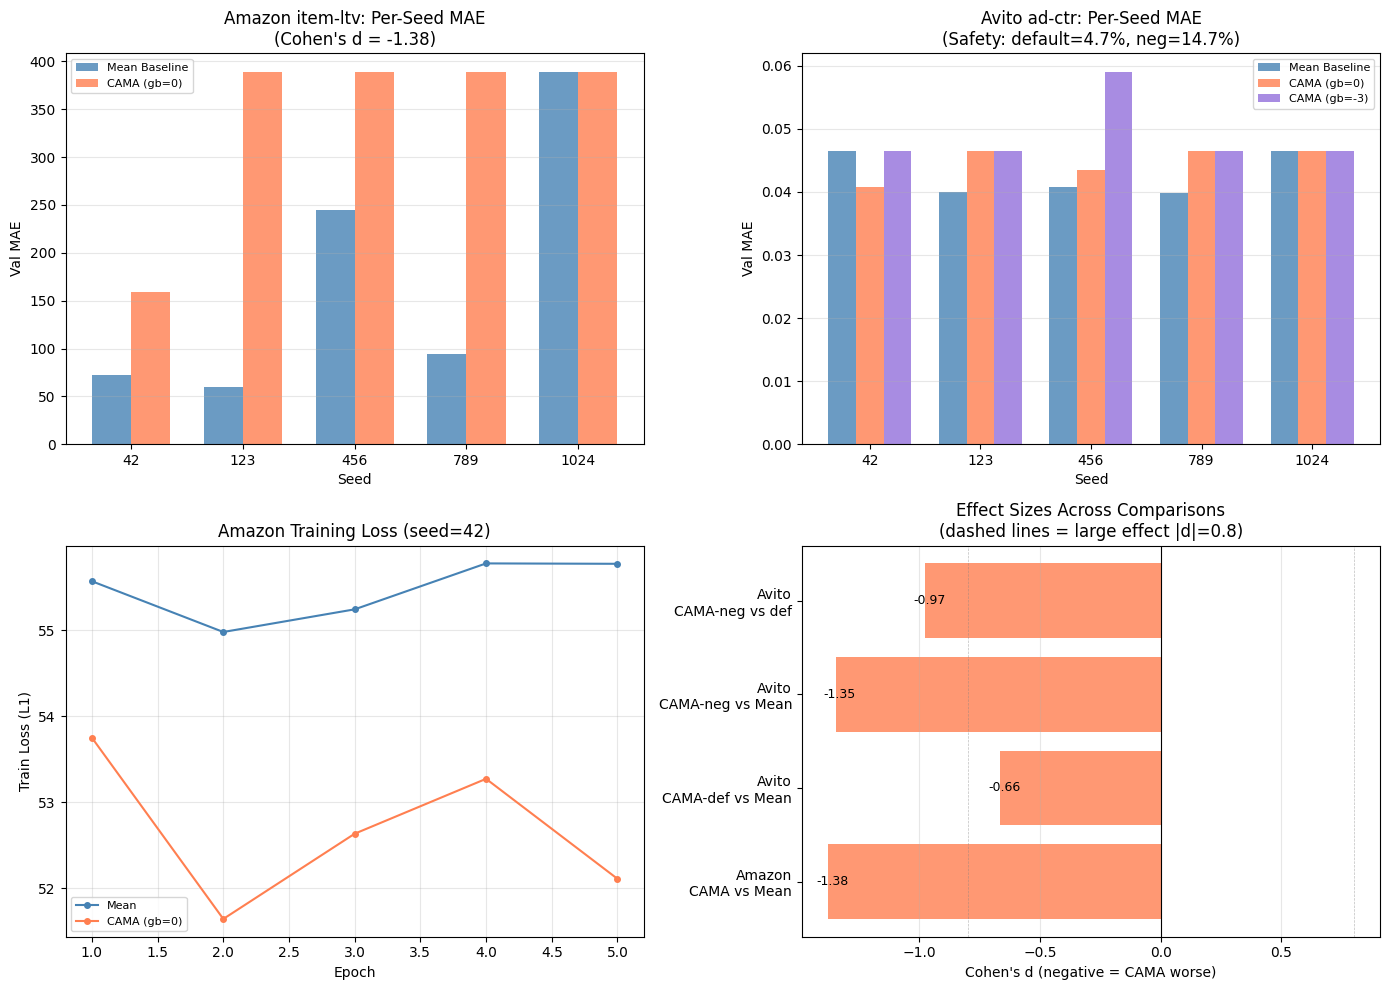

Saved results_summary.png


In [9]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

seeds = [str(s) for s in sorted(data['experiment']['seeds'])]

# ── Plot 1: Amazon per-seed MAE comparison ──
ax = axes[0, 0]
x_pos = np.arange(len(seeds))
width = 0.35
bars1 = ax.bar(x_pos - width/2, amazon_mean, width, label='Mean Baseline', color='steelblue', alpha=0.8)
bars2 = ax.bar(x_pos + width/2, amazon_cama, width, label='CAMA (gb=0)', color='coral', alpha=0.8)
ax.set_xlabel('Seed')
ax.set_ylabel('Val MAE')
ax.set_title(f'Amazon item-ltv: Per-Seed MAE\n(Cohen\'s d = {amazon_stats["cohens_d"]:.2f})')
ax.set_xticks(x_pos)
ax.set_xticklabels(seeds)
ax.legend(fontsize=8)
ax.grid(axis='y', alpha=0.3)

# ── Plot 2: Avito per-seed MAE comparison ──
ax = axes[0, 1]
width = 0.25
bars1 = ax.bar(x_pos - width, avito_mean, width, label='Mean Baseline', color='steelblue', alpha=0.8)
bars2 = ax.bar(x_pos, avito_cama_def, width, label='CAMA (gb=0)', color='coral', alpha=0.8)
bars3 = ax.bar(x_pos + width, avito_cama_neg, width, label='CAMA (gb=-3)', color='mediumpurple', alpha=0.8)
ax.set_xlabel('Seed')
ax.set_ylabel('Val MAE')
ax.set_title(f'Avito ad-ctr: Per-Seed MAE\n(Safety: default={cama_def_pct:.1f}%, neg={cama_neg_pct:.1f}%)')
ax.set_xticks(x_pos)
ax.set_xticklabels(seeds)
ax.legend(fontsize=8)
ax.grid(axis='y', alpha=0.3)

# ── Plot 3: Training loss curves (Amazon, seed 42) ──
ax = axes[1, 0]
for method, color, label in [('mean_baseline', 'steelblue', 'Mean'),
                               ('cama_default', 'coral', 'CAMA (gb=0)')]:
    losses = amazon['per_method'][method]['per_seed']['42']['train_losses']
    ax.plot(range(1, len(losses)+1), losses, 'o-', color=color, label=label, markersize=4)
ax.set_xlabel('Epoch')
ax.set_ylabel('Train Loss (L1)')
ax.set_title('Amazon Training Loss (seed=42)')
ax.legend(fontsize=8)
ax.grid(alpha=0.3)

# ── Plot 4: Cohen's d effect sizes ──
ax = axes[1, 1]
comparisons = ['Amazon\nCAMA vs Mean', 'Avito\nCAMA-def vs Mean',
               'Avito\nCAMA-neg vs Mean', 'Avito\nCAMA-neg vs def']
d_values = [amazon_stats['cohens_d'], avito_stats_def['cohens_d'],
            avito_stats_neg['cohens_d'], avito_stats_neg_vs_def['cohens_d']]
colors_d = ['coral' if d < 0 else 'mediumseagreen' for d in d_values]
bars = ax.barh(comparisons, d_values, color=colors_d, alpha=0.8)
ax.axvline(x=0, color='black', linewidth=0.8)
ax.axvline(x=-0.8, color='gray', linewidth=0.5, linestyle='--', alpha=0.5)
ax.axvline(x=0.8, color='gray', linewidth=0.5, linestyle='--', alpha=0.5)
ax.set_xlabel("Cohen's d (negative = CAMA worse)")
ax.set_title("Effect Sizes Across Comparisons\n(dashed lines = large effect |d|=0.8)")
ax.grid(axis='x', alpha=0.3)
for i, d in enumerate(d_values):
    ax.text(d + 0.05 * np.sign(d), i, f'{d:.2f}', va='center', fontsize=9)

plt.tight_layout()
plt.savefig('results_summary.png', dpi=100, bbox_inches='tight')
plt.show()
print("Saved results_summary.png")

## Summary Table

Final results overview with key metrics for all method comparisons.

In [10]:
from tabulate import tabulate

# Build summary table
rows = []
for dataset_label, part_key in [("Amazon item-ltv", "part_a_amazon"), ("Avito ad-ctr", "part_b_avito")]:
    part = data['results'][part_key]
    for method in part['per_method']:
        pm = part['per_method'][method]
        rows.append([
            dataset_label,
            method,
            f"{pm['mean_mae']:.4f}" if pm['mean_mae'] else "N/A",
            f"{pm['std_mae']:.4f}" if pm['std_mae'] else "N/A",
            f"{pm.get('mean_r2', 'N/A'):.4f}" if isinstance(pm.get('mean_r2'), (int, float)) else "N/A",
        ])

print(tabulate(rows, headers=["Dataset", "Method", "Mean MAE", "Std MAE", "Mean R2"],
               tablefmt="grid"))

# Statistical comparison summary
print("\n")
stat_rows = [
    ["Amazon", "CAMA-default vs Mean", amazon_stats['cohens_d'], amazon_stats['p_value_ttest'],
     f"[{amazon_stats['d_ci_95'][0]:.2f}, {amazon_stats['d_ci_95'][1]:.2f}]"],
    ["Avito", "CAMA-default vs Mean", avito_stats_def['cohens_d'], avito_stats_def['p_value_ttest'],
     f"[{avito_stats_def['d_ci_95'][0]:.2f}, {avito_stats_def['d_ci_95'][1]:.2f}]"],
    ["Avito", "CAMA-neg-init vs Mean", avito_stats_neg['cohens_d'], avito_stats_neg['p_value_ttest'],
     f"[{avito_stats_neg['d_ci_95'][0]:.2f}, {avito_stats_neg['d_ci_95'][1]:.2f}]"],
]
print(tabulate(stat_rows, headers=["Dataset", "Comparison", "Cohen's d", "p-value", "d 95% CI"],
               tablefmt="grid", floatfmt=".4f"))

print("\nKey conclusions:")
print(f"  - Amazon CAMA: DEGRADATION (d={amazon_stats['cohens_d']:.2f}, large negative effect)")
print(f"  - Avito CAMA-default: {cama_def_pct:.1f}% worse than mean (marginal)")
print(f"  - Avito CAMA-neg-init: {cama_neg_pct:.1f}% worse, FAILS 5% safety threshold")
print(f"  - Negative gate init (gb=-3) did NOT fix the degradation issue")

+-----------------+---------------+------------+-----------+-----------+
| Dataset         | Method        |   Mean MAE |   Std MAE |   Mean R2 |
+=================+===============+============+===========+===========+
| Amazon item-ltv | mean_baseline |   171.909  |  142.416  |   -0.1584 |
+-----------------+---------------+------------+-----------+-----------+
| Amazon item-ltv | cama_default  |   343.095  |  103.061  |   -0.4822 |
+-----------------+---------------+------------+-----------+-----------+
| Avito ad-ctr    | mean_baseline |     0.0427 |    0.0035 |   -0.1498 |
+-----------------+---------------+------------+-----------+-----------+
| Avito ad-ctr    | cama_default  |     0.0448 |    0.0026 |   -0.1638 |
+-----------------+---------------+------------+-----------+-----------+
| Avito ad-ctr    | cama_neg_init |     0.049  |    0.0056 |   -0.1805 |
+-----------------+---------------+------------+-----------+-----------+


+-----------+-----------------------+------------